# **1. Install packages**

In [1]:
%%capture
!pip install torchinfo
!pip install torchmetrics

# **2. Import libraries**

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

# Preprocessing
from sklearn.model_selection import train_test_split as tts

# Torch
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from torchinfo import summary
from torchmetrics.classification import BinaryAccuracy

# Metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, recall_score

# os
import os

# Path
from pathlib import Path

# random
import random

# tqdm
from tqdm.auto import tqdm

# typing
from typing import Dict,List

# warnings
import warnings
warnings.filterwarnings("ignore")

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# **3. Load data and EDA**

In [3]:
# Total number of images we have.
IMAGE_PATH = Path("/kaggle/input/autism/AutismDataset/consolidated")
IMAGE_PATH_LIST = list(IMAGE_PATH.glob("*/*.jpg"))
print(f'Total Images = {len(IMAGE_PATH_LIST)}')

Total Images = 2940


In [4]:
# Number of images per class.
classes = os.listdir("/kaggle/input/autism/AutismDataset/consolidated")
classes = sorted(classes, reverse = True)

print("**" * 20)
print(" " * 14, "Classes")
print("**" * 20)
for c in classes:
    img_class_list = list(Path(os.path.join(IMAGE_PATH, c)).glob("*.jpg"))
    print(f"* {c} => {len(img_class_list)} images\n")

****************************************
               Classes
****************************************
* Non_Autistic => 1470 images

* Autistic => 1470 images



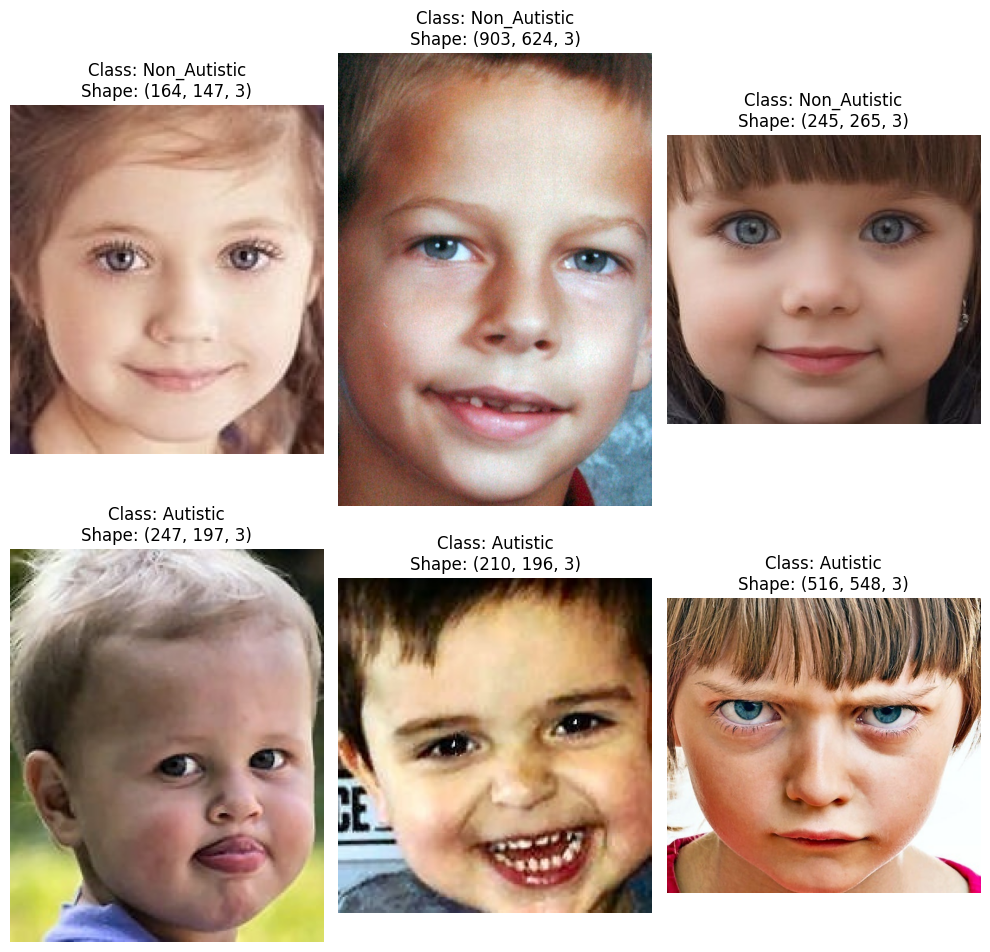

In [5]:
# Now let's visualize some images per class.
NUM_IMAGES = 3

fig, ax = plt.subplots(nrows = len(classes), ncols = NUM_IMAGES, figsize = (10,10))
p = 0
for c in classes:
    img_class_list = list(Path(os.path.join(IMAGE_PATH, c)).glob("*.jpg"))
    imgs_selected = random.choices(img_class_list, k = NUM_IMAGES)
    for i,img_path in enumerate(imgs_selected):
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax[p,i].imshow(img_rgb)
        ax[p,i].set_title(f"Class: {c}\nShape: {img_rgb.shape}")
        ax[p,i].axis("off")
        
    p += 1
    
fig.tight_layout()
fig.show()

We see that the images have different shapes (height and width), for this we will see the distribution of the width and height of the images.

In [6]:
height = [None] * len(IMAGE_PATH_LIST)
width = [None] * len(IMAGE_PATH_LIST)

for i,img_path in enumerate(IMAGE_PATH_LIST):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    height[i] = img_rgb.shape[0]
    width[i] = img_rgb.shape[1]

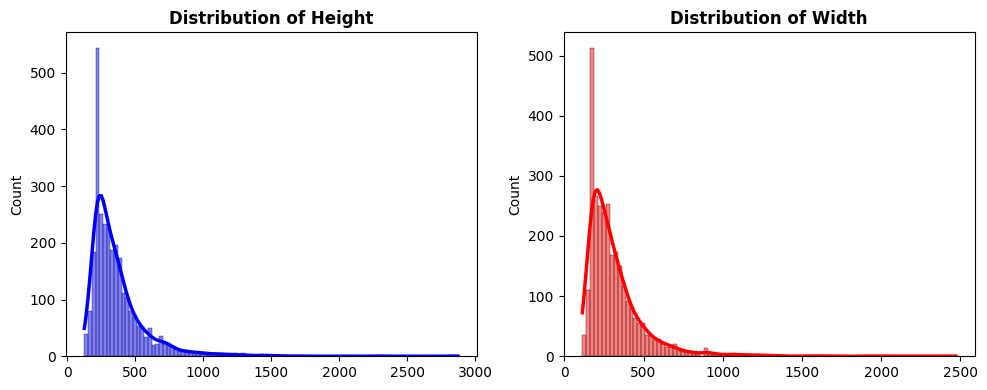

In [7]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))
ax = ax.flat

sns.histplot(height, kde = True, line_kws = {"linewidth":2.5}, color = "blue", ax = ax[0])
ax[0].set_title("Distribution of Height", fontweight = "bold", color = "black")
sns.histplot(width, kde = True, line_kws = {"linewidth":2.5}, color = "red", ax = ax[1])
ax[1].set_title("Distribution of Width", fontweight = "bold", color = "black")

fig.tight_layout()
fig.show()

# **4. Preprocessing**

In [8]:
# Now we create a pd.DataFrame where we store the paths and labels of the images.
images_path = [None] * len(IMAGE_PATH_LIST)
labels = [None] * len(IMAGE_PATH_LIST)

for i,img_path in enumerate(IMAGE_PATH_LIST):
    images_path[i] = img_path
    labels[i] = img_path.parent.stem
    
df_path_label = pd.DataFrame({'path':images_path, 
                              'label':labels})
df_path_label.head()

,path,label
0,/kaggle/input/autism/AutismDataset/consolidate...,Autistic
1,/kaggle/input/autism/AutismDataset/consolidate...,Autistic
2,/kaggle/input/autism/AutismDataset/consolidate...,Autistic
3,/kaggle/input/autism/AutismDataset/consolidate...,Autistic
4,/kaggle/input/autism/AutismDataset/consolidate...,Autistic


In [9]:
# We are going to define the mapping to convert our labels to binary code.
label_map = dict(zip(classes, np.arange(0,2, dtype = 'float32')))
label_map

{'Non_Autistic': 0.0, 'Autistic': 1.0}

In [10]:
# We are going to divide our created dataframe into 3 data sets:
# Train: 70%
# Valid: 15%
# Test: 15%

SEED = 42
df_train, df_rest = tts(df_path_label, 
                        test_size = 0.3, 
                        random_state = SEED, 
                        stratify = df_path_label["label"])

df_valid, df_test = tts(df_rest, 
                        test_size = 0.5, 
                        random_state = SEED, 
                        stratify = df_rest["label"])

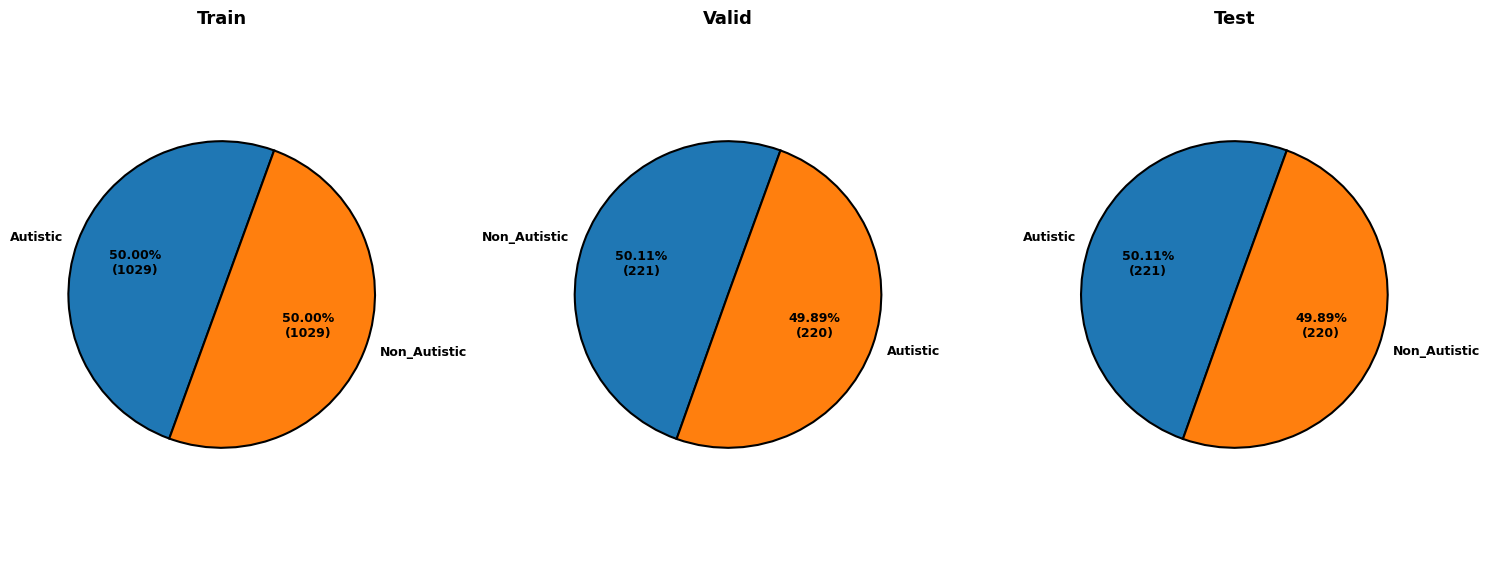

In [11]:
# Visualization of the objective variable in the training, valid and test set.
df_pct_train = df_train["label"].value_counts().to_frame()
labels_train = df_pct_train.index.to_list()
values_train = df_pct_train.iloc[:,0]

df_pct_valid = df_valid["label"].value_counts().to_frame()
labels_valid = df_pct_valid.index.to_list()
values_valid = df_pct_valid.iloc[:,0]

df_pct_test = df_test["label"].value_counts().to_frame()
labels_test = df_pct_test.index.to_list()
values_test = df_pct_test.iloc[:,0]


fig,axes = plt.subplots(nrows = 1, ncols = 3, figsize = (15,6))

def autopct_fun(abs_values):
    gen = iter(abs_values)
    return lambda pct: f"{pct:.2f}%\n({next(gen)})"

# Train
axes[0].pie(x = values_train, 
            labels = labels_train, 
            autopct = autopct_fun(values_train),
            wedgeprops = {'linewidth':1.5, 'edgecolor':'black'},
            textprops = {'fontsize':9, 'fontweight':'bold'}, 
            startangle = 70)
axes[0].set_title('Train', fontsize = 13, fontweight = 'bold', color = 'black')
axes[0].axis("equal")

# Valid
axes[1].pie(x = values_valid, 
            labels = labels_valid, 
            autopct = autopct_fun(values_valid),
            wedgeprops = {'linewidth':1.5, 'edgecolor':'black'},
            textprops = {'fontsize':9, 'fontweight':'bold'}, 
            startangle = 70)
axes[1].set_title('Valid', fontsize = 13, fontweight = 'bold', color = 'black')
axes[1].axis("equal")

# Test
axes[2].pie(x = values_test, 
            labels = labels_test, 
            autopct = autopct_fun(values_test),
            wedgeprops = {'linewidth':1.5, 'edgecolor':'black'},
            textprops = {'fontsize':9, 'fontweight':'bold'}, 
            startangle = 70)
axes[2].set_title('Test', fontsize = 13, fontweight = 'bold', color = 'black')
axes[2].axis("equal")

fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.show()

The classes are balanced, great.

The class we are interested in predicting is `Autistic`.

Now we apply the mapping to our labels.

In [12]:
df_train["label"] = df_train["label"].map(label_map)
df_valid["label"] = df_valid["label"].map(label_map)

Next, we need to reset the indexes of our dataframes to maintain order.

In [13]:
df_train = df_train.reset_index(drop = True)
df_valid = df_valid.reset_index(drop = True)

Now we have to define the transformations that we apply to our images.

In [14]:
weights = ResNet50_Weights.DEFAULT
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

We reach this stage where we have to create our `Dataset's` and `DataLoader's`.

Let's start by creating our **Dataset's**

In [15]:
class CustomDataset(Dataset):
    def __init__(self, df:pd.DataFrame, transforms):
        self.df = df
        self.transforms = transforms
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        image_path = self.df.iloc[idx, 0]
        image = Image.open(image_path).convert("RGB")
        image = self.transforms(image)
        label = self.df.iloc[idx, 1]
        
        return image,label

In [16]:
train_dataset = CustomDataset(df_train, auto_transforms)
valid_dataset = CustomDataset(df_valid, auto_transforms)

Now we create our **DataLoader's**.

In [17]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(dataset = train_dataset, 
                              batch_size = BATCH_SIZE, 
                              shuffle = True, 
                              num_workers = NUM_WORKERS)

valid_dataloader = DataLoader(dataset = valid_dataset, 
                              batch_size = BATCH_SIZE, 
                              shuffle = False, 
                              num_workers = NUM_WORKERS)

In [18]:
# Let's take a look at a batch.
batch_images, labels_batch = next(iter(train_dataloader))

batch_images.shape, labels_batch.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

Great!!, our `DataLoader's` turned out well.

Now we move on to the modeling stage.

# **5. Model**

In [19]:
# GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [20]:
# We define our model with the pretrained weights.
# We will use the Resnet50 model.

model = resnet50(weights = weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 114MB/s] 


In [21]:
# Let's visualize the architecture of the model.
summary(model = model, 
        input_size = [4,3,224,224], 
        col_names = ["input_size", "output_size", "num_params", "trainable"], 
        col_width = 17, 
        row_settings = ["var_names"])

Layer (type (var_name))                  Input Shape       Output Shape      Param #           Trainable
ResNet (ResNet)                          [4, 3, 224, 224]  [4, 1000]         --                True
├─Conv2d (conv1)                         [4, 3, 224, 224]  [4, 64, 112, 112] 9,408             True
├─BatchNorm2d (bn1)                      [4, 64, 112, 112] [4, 64, 112, 112] 128               True
├─ReLU (relu)                            [4, 64, 112, 112] [4, 64, 112, 112] --                --
├─MaxPool2d (maxpool)                    [4, 64, 112, 112] [4, 64, 56, 56]   --                --
├─Sequential (layer1)                    [4, 64, 56, 56]   [4, 256, 56, 56]  --                True
│    └─Bottleneck (0)                    [4, 64, 56, 56]   [4, 256, 56, 56]  --                True
│    │    └─Conv2d (conv1)               [4, 64, 56, 56]   [4, 64, 56, 56]   4,096             True
│    │    └─BatchNorm2d (bn1)            [4, 64, 56, 56]   [4, 64, 56, 56]   128               True

In [22]:
# Now we have to freeze the parameters of the extractor layers.
for param in model.parameters():
    param.requires_grad = False

In [23]:
# Let's see if the parameters are frozen.
summary(model = model, 
        input_size = [4,3,224,224], 
        col_names = ["input_size", "output_size", "num_params", "trainable"], 
        col_width = 17, 
        row_settings = ["var_names"])

Layer (type (var_name))                  Input Shape       Output Shape      Param #           Trainable
ResNet (ResNet)                          [4, 3, 224, 224]  [4, 1000]         --                False
├─Conv2d (conv1)                         [4, 3, 224, 224]  [4, 64, 112, 112] (9,408)           False
├─BatchNorm2d (bn1)                      [4, 64, 112, 112] [4, 64, 112, 112] (128)             False
├─ReLU (relu)                            [4, 64, 112, 112] [4, 64, 112, 112] --                --
├─MaxPool2d (maxpool)                    [4, 64, 112, 112] [4, 64, 56, 56]   --                --
├─Sequential (layer1)                    [4, 64, 56, 56]   [4, 256, 56, 56]  --                False
│    └─Bottleneck (0)                    [4, 64, 56, 56]   [4, 256, 56, 56]  --                False
│    │    └─Conv2d (conv1)               [4, 64, 56, 56]   [4, 64, 56, 56]   (4,096)           False
│    │    └─BatchNorm2d (bn1)            [4, 64, 56, 56]   [4, 64, 56, 56]   (128)           

Perfect!!, now we only need to modify the last layer according to our purpose.

In [24]:
# Let's visualize the last layer.
model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [25]:
output_shape = 1 # binary classification

model.fc = nn.Linear(in_features = 2048, out_features = output_shape, bias = True)

In [26]:
# Let's do one last view of the model to see if it has been modified.
summary(model = model, 
        input_size = [4,3,224,224], 
        col_names = ["input_size", "output_size", "num_params", "trainable"], 
        col_width = 17, 
        row_settings = ["var_names"])

Layer (type (var_name))                  Input Shape       Output Shape      Param #           Trainable
ResNet (ResNet)                          [4, 3, 224, 224]  [4, 1]            --                Partial
├─Conv2d (conv1)                         [4, 3, 224, 224]  [4, 64, 112, 112] (9,408)           False
├─BatchNorm2d (bn1)                      [4, 64, 112, 112] [4, 64, 112, 112] (128)             False
├─ReLU (relu)                            [4, 64, 112, 112] [4, 64, 112, 112] --                --
├─MaxPool2d (maxpool)                    [4, 64, 112, 112] [4, 64, 56, 56]   --                --
├─Sequential (layer1)                    [4, 64, 56, 56]   [4, 256, 56, 56]  --                False
│    └─Bottleneck (0)                    [4, 64, 56, 56]   [4, 256, 56, 56]  --                False
│    │    └─Conv2d (conv1)               [4, 64, 56, 56]   [4, 64, 56, 56]   (4,096)           False
│    │    └─BatchNorm2d (bn1)            [4, 64, 56, 56]   [4, 64, 56, 56]   (128)         

We have to define our `loss function` and `optimizer`.

In [27]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01, weight_decay = 0.1)

Now we define 3 functions to execute the training:
- `train_step`
- `valid_step`
- `train`

In [28]:
def train_step(model:torch.nn.Module, 
               dataloader:torch.utils.data.DataLoader, 
               loss_fn:torch.nn.Module, 
               optimizer:torch.optim.Optimizer):
    
    model.train()
    
    train_loss = 0.
    accuracy_train = BinaryAccuracy(threshold = 0.5).to(device)
    
    for batch,(X,y) in enumerate(dataloader):
        X,y = X.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred_logit = model(X)
        y_pred_logit = y_pred_logit.squeeze(dim = 1)
        loss = loss_fn(y_pred_logit, y)
        train_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
        y_pred_prob = torch.sigmoid(y_pred_logit)
        accuracy_train.update(y_pred_prob, y)
        
    train_loss = train_loss/len(dataloader)
    train_accuracy = accuracy_train.compute()
    
    accuracy_train.reset()
    
    return train_loss, train_accuracy

In [29]:
def save_checkpoint(filename, model, epoch, loss, optimizer, metric):
    state = {"filename":filename, 
             "model":model.state_dict(), 
             "epoch":epoch, 
             "loss":loss, 
             "optimizer":optimizer.state_dict(), 
             "metric":metric}
    
    torch.save(state, filename)

In [30]:
def valid_step(model:torch.nn.Module, 
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module):
    
    model.eval()
    
    valid_loss = 0.
    accuracy_valid = BinaryAccuracy(threshold = 0.5).to(device)
    
    with torch.inference_mode():
        for batch,(X,y) in enumerate(dataloader):
            X,y = X.to(device), y.to(device)
            y_pred_logit = model(X)
            y_pred_logit = y_pred_logit.squeeze(dim = 1)
            loss = loss_fn(y_pred_logit, y)
            valid_loss += loss.item()
            
            y_pred_prob = torch.sigmoid(y_pred_logit)
            accuracy_valid.update(y_pred_prob, y)
            
    valid_loss = valid_loss/len(dataloader)
    valid_accuracy = accuracy_valid.compute()
    
    accuracy_valid.reset()
    
    return valid_loss, valid_accuracy

In [31]:
def train(model:torch.nn.Module, 
          train_dataloader:torch.utils.data.DataLoader, 
          valid_dataloader:torch.utils.data.DataLoader, 
          loss_fn:torch.nn.Module, 
          optimizer:torch.optim.Optimizer, 
          epochs:int = 10):
    
    results = {"train_loss":[], 
               "train_accuracy":[], 
               "valid_loss":[], 
               "valid_accuracy":[]}
    
    best_valid_loss = float("inf")
    
    for epoch in tqdm(range(epochs)):
        train_loss, train_accuracy = train_step(model = model, 
                                                dataloader = train_dataloader, 
                                                loss_fn = loss_fn, 
                                                optimizer = optimizer)
        
        valid_loss, valid_accuracy = valid_step(model = model, 
                                                dataloader = valid_dataloader, 
                                                loss_fn = loss_fn)
        
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            file_name = "best_model.pt"
            save_checkpoint(file_name, 
                            model, 
                            epoch, 
                            best_valid_loss, 
                            optimizer, 
                            valid_accuracy)
            
        
        print(f"Epoch: {epoch + 1} | ", 
              f"Train Loss: {train_loss:.4f} | ", 
              f"Train Accuracy: {train_accuracy:.4f} | ", 
              f"Valid Loss: {valid_loss:.4f} | ", 
              f"Valid Accuracy: {valid_accuracy:.4f}")
        
        results["train_loss"].append(train_loss)
        results["train_accuracy"].append(train_accuracy)
        results["valid_loss"].append(valid_loss)
        results["valid_accuracy"].append(valid_accuracy)
        
    return results

In [32]:
# We execute the training!!!
EPOCHS = 100

torch.cuda.manual_seed(SEED)
torch.manual_seed(SEED)

MODEL_RESULTS = train(model.to(device), train_dataloader, valid_dataloader, loss_fn, optimizer, EPOCHS)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1 |  Train Loss: 0.5624 |  Train Accuracy: 0.7109 |  Valid Loss: 0.5748 |  Valid Accuracy: 0.6757
Epoch: 2 |  Train Loss: 0.5495 |  Train Accuracy: 0.7225 |  Valid Loss: 0.5734 |  Valid Accuracy: 0.6848
Epoch: 3 |  Train Loss: 0.5443 |  Train Accuracy: 0.7274 |  Valid Loss: 0.5893 |  Valid Accuracy: 0.6667
Epoch: 4 |  Train Loss: 0.5424 |  Train Accuracy: 0.7328 |  Valid Loss: 0.6507 |  Valid Accuracy: 0.6077
Epoch: 5 |  Train Loss: 0.5539 |  Train Accuracy: 0.7250 |  Valid Loss: 0.5313 |  Valid Accuracy: 0.7415
Epoch: 6 |  Train Loss: 0.5333 |  Train Accuracy: 0.7303 |  Valid Loss: 0.5164 |  Valid Accuracy: 0.7732
Epoch: 7 |  Train Loss: 0.5368 |  Train Accuracy: 0.7420 |  Valid Loss: 0.5325 |  Valid Accuracy: 0.7460
Epoch: 8 |  Train Loss: 0.5548 |  Train Accuracy: 0.7206 |  Valid Loss: 0.5788 |  Valid Accuracy: 0.7029
Epoch: 9 |  Train Loss: 0.5571 |  Train Accuracy: 0.7153 |  Valid Loss: 0.5181 |  Valid Accuracy: 0.7551
Epoch: 10 |  Train Loss: 0.5401 |  Train Accuracy: 0.73

In [33]:
# Function to plot the loss and metric during each training epoch.
def plot_loss_metric_curve(model_results:Dict[str,List[float]]):
    
    train_loss = model_results["train_loss"]
    valid_loss = model_results["valid_loss"]
    
    train_accuracy = [float(value) for value in model_results["train_accuracy"]]
    valid_accuracy = [float(value) for value in model_results["valid_accuracy"]]
    
    fig,axes = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))
    plt.style.use("ggplot")
    axes = axes.flat
    
    axes[0].plot(train_loss, color = "red", label = "Train")
    axes[0].plot(valid_loss, color = "blue", label = "Valid")
    axes[0].set_title("BCEWithLogitsLoss", fontsize = 12, fontweight = "bold", color = "black")
    axes[0].set_xlabel("Epochs", fontsize = 10, fontweight = "bold", color = "black")
    axes[0].set_ylabel("Loss", fontsize = 10, fontweight = "bold", color = "black")
    axes[0].legend()
    
    axes[1].plot(train_accuracy, color = "red", label = "Train")
    axes[1].plot(valid_accuracy, color = "blue", label = "Valid")
    axes[1].set_title("Metric of performance: Accuracy", fontsize = 12, fontweight = "bold", color = "black")
    axes[1].set_xlabel("Epochs", fontsize = 10, fontweight = "bold", color = "black")
    axes[1].set_ylabel("Score", fontsize = 10, fontweight = "bold", color = "black")
    axes[1].legend()
    
    fig.tight_layout()
    fig.show()

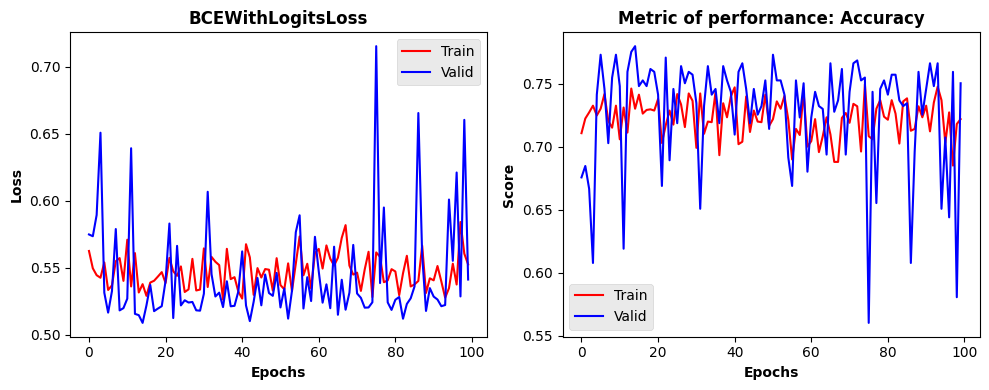

In [34]:
plot_loss_metric_curve(MODEL_RESULTS)

In [35]:
# Let's upload the best model
checkpoint_path = "/kaggle/working/best_model.pt"
checkpoint = torch.load(checkpoint_path)

In [36]:
# Let's look at the smallest loss, in what epoch it occurred and its metric.
print(f"Best Loss: {checkpoint['loss']}")
print(f"Epoch: {checkpoint['epoch'] + 1}")
print(f"Metric: {checkpoint['metric']}")

Best Loss: 0.5087298303842545
Epoch: 15
Metric: 0.7800453305244446


# **6. Metrics**

Let's see how good a classifier our model is, to do this we will visualize the following:
- `Accuracy`
- `Recall`
- `Confusion Matrix`
- `Classification Report`

But first we need to make the predictions on both data sets (training and validation).

**Predictions**

In [37]:
model.load_state_dict(checkpoint["model"])

y_pred_train = []
y_pred_valid = []

model.eval()

with torch.inference_mode():
    for batch,(X_train, y_train) in enumerate(train_dataloader):
        X_train, y_train = X_train.to(device), y_train.to(device)
        y_pred_logit_train = model(X_train)
        y_pred_logit_train = y_pred_logit_train.squeeze(dim = 1)
        y_pred_prob_train = torch.sigmoid(y_pred_logit_train.cpu())
        y_pred_class_train = torch.round(y_pred_prob_train)
        y_pred_train.append(y_pred_class_train)
        
    for batch,(X_valid, y_valid) in enumerate(valid_dataloader):
        X_valid, y_valid = X_valid.to(device), y_valid.to(device)
        y_pred_logit_valid = model(X_valid)
        y_pred_logit_valid = y_pred_logit_valid.squeeze(dim = 1)
        y_pred_prob_valid = torch.sigmoid(y_pred_logit_valid.cpu())
        y_pred_class_valid = torch.round(y_pred_prob_valid)
        y_pred_valid.append(y_pred_class_valid)

In [38]:
# We convert to np.ndarray format to calculate our metrics.
y_pred_train = torch.cat(y_pred_train).numpy()
y_pred_valid = torch.cat(y_pred_valid).numpy()

- **`Accuracy`**

In [39]:
print(f"Train Accuracy: {round(accuracy_score(df_train['label'], y_pred_train), 4)}")
print(f"Valid Accuracy: {round(accuracy_score(df_valid['label'], y_pred_valid), 4)}")

Train Accuracy: 0.5151
Valid Accuracy: 0.78


- **`Recall`**

In [40]:
print(f"Train Recall: {round(recall_score(df_train['label'], y_pred_train), 4)}")
print(f"Valid Recall: {round(recall_score(df_valid['label'], y_pred_valid), 4)}")

Train Recall: 0.585
Valid Recall: 0.8273


- **`Confusion Matrix`**

In [41]:
confusion_matrix_train = confusion_matrix(np.array(df_train["label"]).astype(int), y_pred_train.astype(int))
confusion_matrix_valid = confusion_matrix(np.array(df_valid["label"]).astype(int), y_pred_valid.astype(int))

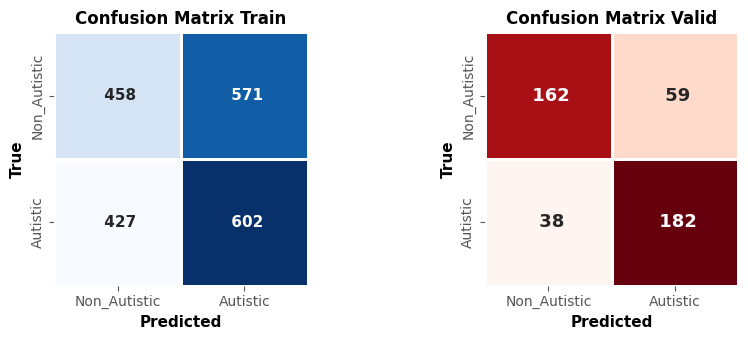

In [42]:
# Confusion Matrix Plot
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = (9,3.5))
ax = ax.flat
sns.heatmap(confusion_matrix_train, 
            cmap = 'Blues', 
            annot = True, 
            fmt = ' ', 
            annot_kws = {"fontsize":11, 
                         "fontweight":"bold"}, 
            linewidths = 1, 
            linecolor = "white", 
            cbar = False, 
            square = True, 
            xticklabels = classes,
            yticklabels = classes,
            ax = ax[0])
ax[0].set_xlabel("Predicted", fontsize = 11, fontweight = "bold", color = "black")
ax[0].set_ylabel("True", fontsize = 11, fontweight = "bold", color = "black")
ax[0].set_title('Confusion Matrix Train', fontsize = 12, fontweight = 'bold', color = 'black')

sns.heatmap(confusion_matrix_valid, 
            cmap = 'Reds', 
            annot = True, 
            fmt = ' ', 
            annot_kws = {"fontsize":13, 
                         "fontweight":"bold"}, 
            linewidths = 1, 
            linecolor = "white", 
            cbar = False, 
            square = True, 
            xticklabels = classes, 
            yticklabels = classes,
            ax = ax[1])
ax[1].set_xlabel("Predicted", fontsize = 11, fontweight = "bold", color = "black")
ax[1].set_ylabel("True", fontsize = 11, fontweight = "bold", color = "black")
ax[1].set_title('Confusion Matrix Valid', fontsize = 12, fontweight = 'bold', color = 'black')

fig.tight_layout()
fig.show()

- **`Classification Report`**

In [43]:
# To perform a reverse mapping, go from id to label.
id2label = dict(zip(np.arange(0,2, dtype = 'float32'),classes))
id2label

{0.0: 'Non_Autistic', 1.0: 'Autistic'}

In [44]:
print("=="*40)
print(" " * 25, "Classification Report Train")
print("=="*40)
print(classification_report(df_train["label"].map(id2label), 
                            pd.Series(y_pred_train).map(id2label)))

print("=="*40)
print(" " * 25, "Classification Report Valid")
print("=="*40)
print(classification_report(df_valid["label"].map(id2label), 
                            pd.Series(y_pred_valid).map(id2label)))

                          Classification Report Train
              precision    recall  f1-score   support

    Autistic       0.51      0.59      0.55      1029
Non_Autistic       0.52      0.45      0.48      1029

    accuracy                           0.52      2058
   macro avg       0.52      0.52      0.51      2058
weighted avg       0.52      0.52      0.51      2058

                          Classification Report Valid
              precision    recall  f1-score   support

    Autistic       0.76      0.83      0.79       220
Non_Autistic       0.81      0.73      0.77       221

    accuracy                           0.78       441
   macro avg       0.78      0.78      0.78       441
weighted avg       0.78      0.78      0.78       441



# **7. Predictions Test Images**

Let's create a class to apply all the transformations we have done and finally predict the class.

In [45]:
class Predictions:
    def __init__(self, df:pd.DataFrame, transforms):
        self.df = df
        self.transforms = transforms
        
    def predictions(self):
        df_new = self.df.copy()
        df_new["label"] = df_new["label"].map(label_map)
        df_new = df_new.reset_index(drop = True)
        dataset = CustomDataset(df_new, self.transforms)
        dataloader = DataLoader(dataset = dataset, 
                                batch_size = BATCH_SIZE, 
                                shuffle = False,
                                num_workers = NUM_WORKERS)
    
        y_predictions = []
        model.load_state_dict(checkpoint["model"])
        model.eval()
        with torch.inference_mode():
            for batch,(X,y) in enumerate(dataloader):
                X,y = X.to(device), y.to(device)
                y_pred_logit = model(X)
                y_pred_logit = y_pred_logit.squeeze(dim = 1)
                y_pred_prob = torch.sigmoid(y_pred_logit.cpu())
                y_pred_class = torch.round(y_pred_prob)
                y_predictions.append(y_pred_class)
                
        y_predictions_labels = pd.Series(torch.cat(y_predictions, dim = 0).numpy()).map(id2label)
                
        return y_predictions_labels
        

In [46]:
predictions = Predictions(df_test,auto_transforms)
predictions_test = predictions.predictions()
predictions_test

0          Autistic
1          Autistic
2          Autistic
3          Autistic
4      Non_Autistic
           ...     
436    Non_Autistic
437    Non_Autistic
438        Autistic
439        Autistic
440    Non_Autistic
Length: 441, dtype: object

In [47]:
print(f'Accuracy Test = {accuracy_score(df_test["label"], predictions_test)}')

Accuracy Test = 0.7913832199546486


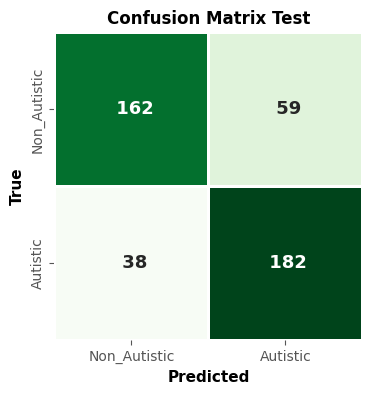

In [48]:
confusion_matrix_test = confusion_matrix(df_test["label"], predictions_test)

fig,ax = plt.subplots(figsize = (5,4))
sns.heatmap(confusion_matrix_valid, 
            cmap = 'Greens', 
            annot = True, 
            fmt = ' ', 
            annot_kws = {"fontsize":13, 
                         "fontweight":"bold"}, 
            linewidths = 1, 
            linecolor = "white", 
            cbar = False, 
            square = True, 
            xticklabels = classes, 
            yticklabels = classes,
            ax = ax)
ax.set_xlabel("Predicted", fontsize = 11, fontweight = "bold", color = "black")
ax.set_ylabel("True", fontsize = 11, fontweight = "bold", color = "black")
ax.set_title('Confusion Matrix Test', fontsize = 12, fontweight = 'bold', color = 'black')
fig.show()